# Single-Facility Siting: Weighted Median Problem and the Gravity Model

**Problem.** A manufacturer wants to site one new plant. The plant receives components from six suppliers and ships finished goods to five distributors. Each partner runs its own truck fleet and charges its own rate (dollars to move one truckload one mile), and each moves a known number of truckloads per period. Given the map coordinates of all eleven existing facilities, where should the new plant go so that total transportation cost is minimised?

This is the classic **weighted Weber problem** (also called the single-facility minisum or weighted median problem) with Euclidean distances. The notebook solves it two ways:

1. **Direct nonlinear optimisation** of the total-cost surface (`scipy.optimize`).
2. **The iterative gravity model** (Weiszfeld's algorithm), started from the origin and run for ten iterations, to show how the heuristic converges to the same point.

## Formulation

**Parameters** (for each existing facility $i = 1,\ldots,n$):

| Symbol | Meaning |
| --- | --- |
| $(x_i, y_i)$ | Map coordinates of facility $i$, in miles |
| $F_i$ | Transport charge of facility $i$, in \$ per truckload-mile |
| $D_i$ | Truckloads moved between facility $i$ and the new plant |
| $w_i = F_i D_i$ | Composite weight — cost per mile of serving facility $i$ |

**Decision variables:** $x, y$ — the coordinates of the new plant.

**Model:**

$$
\min_{x,\,y} \; \sum_{i=1}^{n} w_i \, d_i(x, y)
\qquad \text{where} \qquad
d_i(x, y) = \sqrt{(x - x_i)^2 + (y - y_i)^2}
$$

The objective is convex (a positively weighted sum of Euclidean norms), so any local
minimum is global.

**Gravity model (Weiszfeld's algorithm).** Setting the gradient to zero and rearranging gives
a fixed-point update: given the current point $(x^k, y^k)$,

$$
x^{k+1} = \frac{\sum_i w_i x_i / d_i^k}{\sum_i w_i / d_i^k},
\qquad
y^{k+1} = \frac{\sum_i w_i y_i / d_i^k}{\sum_i w_i / d_i^k},
\qquad d_i^k = d_i(x^k, y^k).
$$

Each new point is a weighted average of the existing locations, where the weight of each
location is inflated by its cost rate and deflated by its current distance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import minimize

## 1. Data

Eleven existing facilities: six suppliers and five distributors.

In [2]:
facilities = pd.DataFrame(
    [
        ("Supplier",    "A", 4.74, 7, 293, 240),
        ("Supplier",    "B", 7.32, 3, 490, 155),
        ("Supplier",    "C", 6.94, 6, 496, 255),
        ("Supplier",    "D", 7.10, 2, 275, 175),
        ("Supplier",    "E", 3.50, 5, 304, 176),
        ("Supplier",    "F", 6.85, 7, 349, 326),
        ("Distributor", "1", 6.63, 4, 154, 498),
        ("Distributor", "2", 3.44, 7, 211, 211),
        ("Distributor", "3", 7.04, 3, 166, 354),
        ("Distributor", "4", 3.30, 8, 208, 312),
        ("Distributor", "5", 3.17, 1, 194, 295),
    ],
    columns=["role", "id", "rate_per_truckload_mile", "truckloads", "x", "y"],
)

# Composite weight w_i = F_i * D_i -- dollars of cost per mile of separation.
facilities["weight"] = facilities.rate_per_truckload_mile * facilities.truckloads
facilities

,role,id,rate_per_truckload_mile,truckloads,x,y,weight
0,Supplier,A,4.74,7,293,240,33.18
1,Supplier,B,7.32,3,490,155,21.96
2,Supplier,C,6.94,6,496,255,41.64
3,Supplier,D,7.10,2,275,175,14.20
4,Supplier,E,3.50,5,304,176,17.50
5,Supplier,F,6.85,7,349,326,47.95
6,Distributor,1,6.63,4,154,498,26.52
7,Distributor,2,3.44,7,211,211,24.08
8,Distributor,3,7.04,3,166,354,21.12
9,Distributor,4,3.30,8,208,312,26.40


In [3]:
X = facilities.x.to_numpy(dtype=float)
Y = facilities.y.to_numpy(dtype=float)
W = facilities.weight.to_numpy(dtype=float)

def total_cost(point):
    '''Weighted sum of Euclidean distances from point to every existing facility.'''
    px, py = point
    return float(np.sum(W * np.hypot(px - X, py - Y)))

print(f"Cost if the plant were sited at the origin: ${total_cost((0, 0)):,.2f}")

Cost if the plant were sited at the origin: $121,037.16


## 2. Exact solution of the convex program

In [4]:
start = np.array([X.mean(), Y.mean()])
result = minimize(total_cost, start)

x_star, y_star = result.x
cost_star = total_cost(result.x)

print(f"Optimal plant location : ({x_star:,.2f}, {y_star:,.2f})")
print(f"Minimum total cost     : ${cost_star:,.2f}")

Optimal plant location : (298.95, 260.75)
Minimum total cost     : $36,755.49


## 3. Gravity model (Weiszfeld's algorithm)
Started at the origin $(0,0)$ and run for ten iterations, as required. The guard on `d` prevents a division by zero if an iterate lands exactly on an existing facility.

In [5]:
def gravity_model(x0=0.0, y0=0.0, iterations=10, eps=1e-9):
    '''Weiszfeld fixed-point iteration; returns one row per iterate.'''
    point = np.array([float(x0), float(y0)])
    history = [(0, point[0], point[1], total_cost(point))]

    for k in range(1, iterations + 1):
        d = np.maximum(np.hypot(point[0] - X, point[1] - Y), eps)
        share = W / d                      # weight per unit distance
        point = np.array([np.sum(share * X) / share.sum(), 
                          np.sum(share * Y) / share.sum()])
        history.append((k, point[0], point[1], total_cost(point)))
    return pd.DataFrame(history, columns=["iteration", "x", "y", "total_cost"]).set_index("iteration")

iterates = gravity_model()
iterates

,x,y,total_cost
iteration,,,
0,0.000000,0.000000,121037.161811
1,295.317596,274.062537,36888.680622
2,299.425880,268.672151,36789.510156
3,300.278232,265.893770,36769.038733
4,300.181496,264.293159,36762.081724
5,299.906961,263.267067,36758.873500
6,299.656500,262.565209,36757.257555
7,299.464365,262.069195,36756.422154
8,299.323943,261.712999,36755.984761


In [6]:
final = iterates.iloc[-1]
comparison = pd.DataFrame(
    {
        "x": [final.x, x_star], "y": [final.y, y_star],
        "total_cost": [final.total_cost, cost_star],
    },
    index=["Gravity model (10 iterations)", "Convex optimum"],
)
comparison["gap_vs_optimum"] = comparison.total_cost - cost_star
comparison.round(2)

,x,y,total_cost,gap_vs_optimum
Gravity model (10 iterations),299.15,261.27,36755.63,0.14
Convex optimum,298.95,260.75,36755.49,0.00


## 4. Convergence behaviour

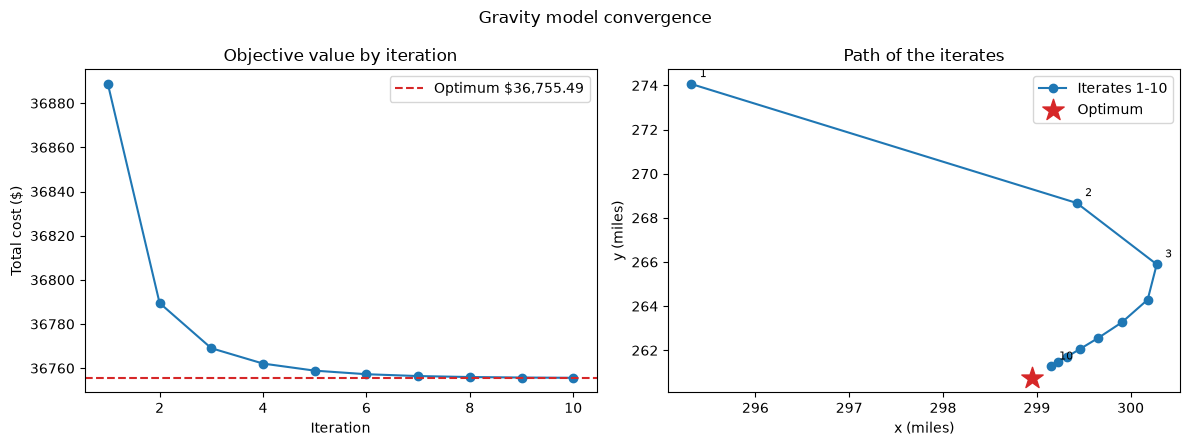

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(iterates.index[1:], iterates.total_cost[1:], "o-", color="#1f77b4")
axes[0].axhline(cost_star, ls="--", color="#d62728", label=f"Optimum ${cost_star:,.2f}")
axes[0].set(xlabel="Iteration", ylabel="Total cost ($)", title="Objective value by iteration")
axes[0].legend()

axes[1].plot(iterates.x[1:], iterates.y[1:], "o-", color="#1f77b4", label="Iterates 1-10")
axes[1].scatter([x_star], [y_star], marker="*", s=260, color="#d62728", zorder=5, label="Optimum")
for k, row in iterates.iloc[1:].iterrows():
    if k in (1, 2, 3, 10):
        axes[1].annotate(k, (row.x, row.y), textcoords="offset points", xytext=(6, 5), fontsize=8)
axes[1].set(xlabel="x (miles)", ylabel="y (miles)", title="Path of the iterates")
axes[1].legend()

fig.suptitle("Gravity model convergence")
fig.tight_layout()
plt.show()

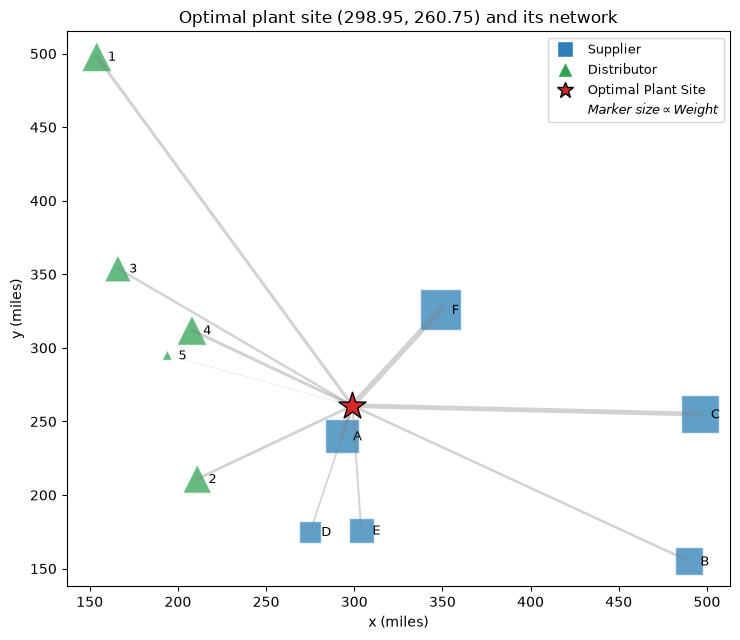

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))

for role, marker, colour in [("Supplier", "s", "#2c7fb8"), ("Distributor", "^", "#31a354")]:
    sub = facilities[facilities.role == role]
    ax.scatter(sub.x, sub.y, s=18 * sub.weight, marker=marker, alpha=0.75, color=colour, edgecolor="white")
    for _, row in sub.iterrows():
        ax.annotate(row.id, (row.x, row.y), textcoords="offset points", xytext=(8, -3), fontsize=9)

ax.scatter([x_star], [y_star], marker="*", s=420, color="#d62728", edgecolor="black", zorder=5)
for _, row in facilities.iterrows():
    ax.plot([x_star, row.x], [y_star, row.y], color="grey", lw=row.weight / 12, alpha=0.35, zorder=1)

ax.set(xlabel="x (miles)", ylabel="y (miles)",
       title=f"Optimal plant site ({x_star:,.2f}, {y_star:,.2f}) and its network")

# Fixed-size proxy handles, for Legend-purpose only
legend_handles = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#2c7fb8", markeredgecolor="white", markersize=11, label="Supplier"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#31a354", markeredgecolor="white", markersize=12, label="Distributor"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="#d62728", markeredgecolor="black", markersize=12, label="Optimal Plant Site"),
    Line2D([0], [0], marker="None", color="w", label="$\\it{Marker\\ size \\propto Weight}$"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

## 5. Interpretation
- **The convex program** puts the plant at roughly **(298.95, 260.75)**, with a total transportation cost of about **\$36,755.49**. Sited at the origin, the same network would cost about `$121,000`, so the siting decision is worth roughly two-thirds of the freight bill.
- **The gravity model agrees.** Started from (0, 0), it lands within about a mile of the optimum after a single iteration, and the remaining nine barely move the cost. The tenth iterate is **(299.15, 261.27)** at **\$36,755.63**, which is just `$0.14` above the true optimum, a gap under 0.0004%.
- **The pull of the network is dominated by weight, not by count.** Distributor #4 (8 truckloads at `$3.30`) and Suppliers A and F (7 truckloads each, at `$4.74` and `$6.85`) do most of the pulling, which is why the answer sits east and north of the unweighted average location.